In [1]:
# import libraries
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_histogram

sim = AerSimulator(method='statevector')

In [2]:
# create a Bell state
def create_bell_state(qc, a, b):
    qc.h(a)
    qc.cx(a, b)

In [3]:
def encode_message(qc, a, message):
    if message == '00':
        pass
    elif message == '01':
        qc.x(a)
    elif message == '10':
        qc.z(a)
    elif message == '11':
        qc.x(a)
        qc.z(a)
    else:
        raise ValueError("Invalid message. Must be one of '00', '01', '10', '11'.")

In [4]:
def decode_message(qc, a, b):
    qc.cx(a, b)
    qc.h(a)

In [5]:
# create a quantum circuit for superdense coding
qc = QuantumCircuit(2)
create_bell_state(qc, 0, 1)
qc.barrier()
msg = ''.join(np.random.choice(['0', '1'], size=2))
encode_message(qc, 0, msg)
qc.barrier()
decode_message(qc, 0, 1)
qc.measure_all()

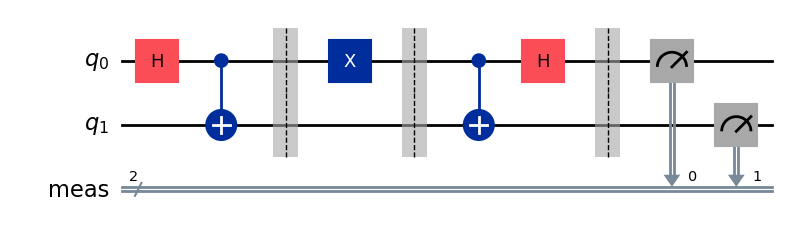

In [6]:
qc.draw('mpl',filename='superdense_coding_circuit.png')

In [7]:
# simulate the circuit
result = sim.run(transpile(qc, sim), shots=1024).result()
counts = result.get_counts()
print("Measurement results:", counts)
# probability of each outcome
total_shots = sum(counts.values())
for outcome, count in counts.items():
    probability = count / total_shots
    print(f"Outcome: {outcome}, Count: {count}, Probability: {probability:.4f}")
# probability show in a histogram

plot_histogram(counts, filename='superdense_coding_results_simulation.png')



Measurement results: {'10': 1024}
Outcome: 10, Count: 1024, Probability: 1.0000


In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# 1. Initialize the service (ensure your token is saved)
# You can save it once via: QiskitRuntimeService.save_account(channel="ibm_quantum", token="YOUR_TOKEN")
service = QiskitRuntimeService(channel="ibm_quantum_platform")

# 2. Select the least busy backend
backend = service.least_busy(simulator=False, operational=True)
print(f"Running on backend: {backend.name}")

# 3. Transpile your circuit for the specific backend
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

# 4. Run the circuit using the Sampler primitive
sampler = Sampler(backend)
job = sampler.run([isa_circuit])
pub_result = job.result()[0]
counts = pub_result.data.meas.get_counts()

print("Measurement results:", counts)



qiskit_runtime_service.__init__:WARNING:2026-06-19 11:53:24,563: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-19 11:53:24,809: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-19 11:53:27,274: Using instance: open-instance, plan: open


Running on backend: ibm_marrakesh
Measurement results: {'10': 3909, '11': 24, '00': 153, '01': 10}


In [9]:
# probability of each outcome
total_shots = sum(counts.values())
for outcome, count in counts.items():
    probability = count / total_shots
    print(f"Outcome: {outcome}, Count: {count}, Probability: {probability:.4f}")
# probability show in a histogram
plot_histogram(counts, filename='superdense_coding_results_realhardware.png')

Outcome: 10, Count: 3909, Probability: 0.9543
Outcome: 11, Count: 24, Probability: 0.0059
Outcome: 00, Count: 153, Probability: 0.0374
Outcome: 01, Count: 10, Probability: 0.0024
